# Test Regular (NumPy/Pandas) Simulation Engine

Quick test to verify the regular simulation engine works and produces reasonable results.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simulation_engine.commands import RunSimulationCommand
from simulation_engine.common.types import SimulationPortfolioWeights, CashFlow
from simulation_engine.common.enums import SimulationType, SimulationStepType, InterpolationMethod


/Users/oliver/Documents/AdviceTools/.venv/lib/python3.12/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'validate_by_name'
* 'validate_all' has been renamed to 'validate_default'
  warnings.warn(message, UserWarning)


In [2]:
# Test parameters
n_sims = 5000
end_step = 60
initial_wealth = 100000


weights = [
    SimulationPortfolioWeights(step=0, stocks=0.9, bonds=0.08),
    SimulationPortfolioWeights(step=40, stocks=0.3, bonds=0.68)
]

cash_flows = [
    CashFlow(step=0, value=25000), # $10k/year
    CashFlow(step=30, value=-40000)

]



In [3]:

command = RunSimulationCommand(
    number_of_simulations=n_sims,
    end_step=end_step,
    weights=weights,
    savings_rates=cash_flows,
    initial_wealth=initial_wealth,
    simulation_type=SimulationType.CHOLESKY,
    step_size=SimulationStepType.ANNUAL,
    weights_interpolation=InterpolationMethod.FFILL,
    savings_rate_interpolation=InterpolationMethod.FFILL
)

result = command.handle()
print(f"Simulation completed in {result.simulation_time:.3f} seconds")
print(f"Time per simulation: {result.simulation_time_per_path:.6f} seconds")


/Users/oliver/Documents/AdviceTools/simulation_engine/commands.py:88: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_sim_data["transactions"] = base_sim_data["transactions"].fillna(0)
/Users/oliver/Documents/AdviceTools/simulation_engine/commands.py:131: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  exp_return['Expected Return'] = exp_return['overrides'].combine_first(exp_return['Expected Return'])


Simulating...
Simulation completed in 0.100 seconds
Time per simulation: 0.000020 seconds


In [4]:
# Check results
sim_data = result.nominal.simulation_data
print(f"Simulation data shape: {sim_data.shape}")
print(f"Final wealth stats:")
print(f"  Mean: ${result.nominal.final_mean:,.0f}")
print(f"  Median: ${result.nominal.final_median:,.0f}")
print(f"  Std: ${result.nominal.final_std:,.0f}")
print(f"  Min: ${result.nominal.final_min:,.0f}")
print(f"  Max: ${result.nominal.final_max:,.0f}")
print(f"Destitution risk: {result.destitution[-1]:.1%}")


Simulation data shape: (5000, 61)
Final wealth stats:
  Mean: $100,480,407
  Median: $58,295,338
  Std: $5,107,918
  Min: $100,000
  Max: $21,589,496
Destitution risk: 3.1%


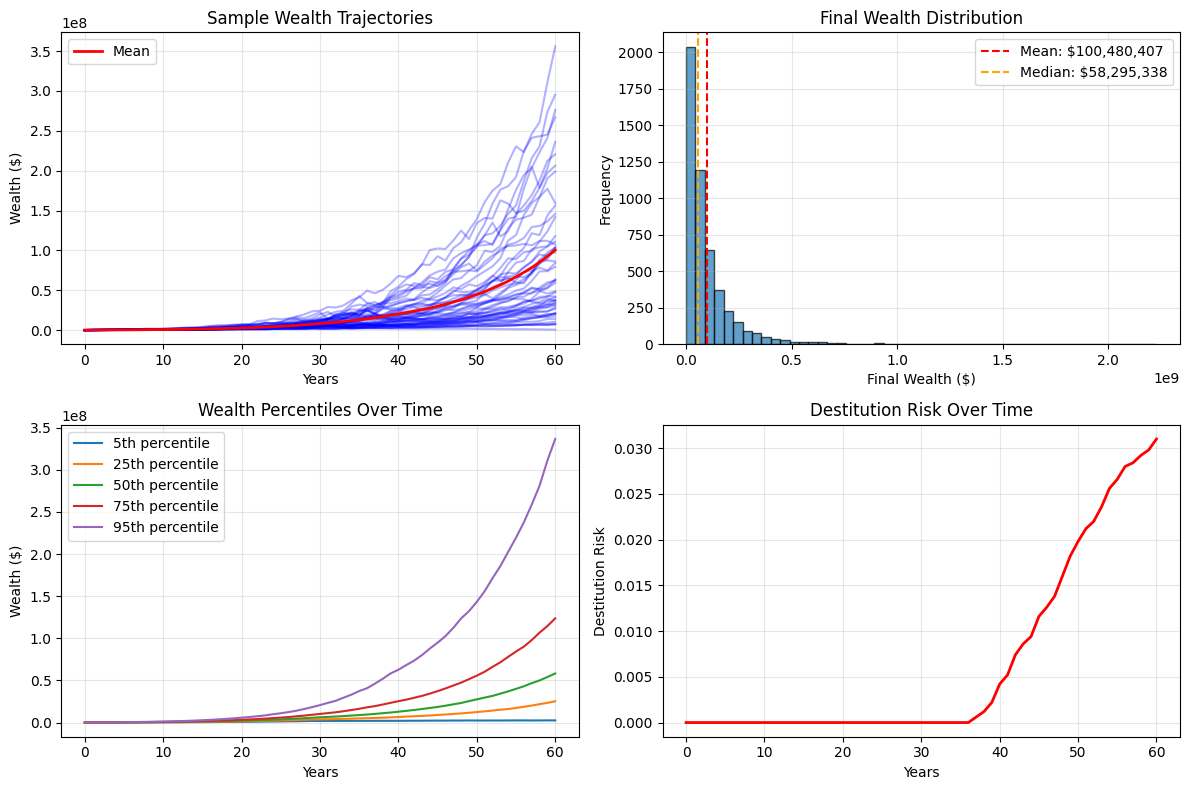

In [5]:
# Plot wealth trajectories
plt.figure(figsize=(12, 8))

# Sample of trajectories
sample_size = 50
sample_indices = np.random.choice(n_sims, sample_size, replace=False)

plt.subplot(2, 2, 1)
for i in sample_indices:
    plt.plot(sim_data[i, :], alpha=0.3, color='blue')
plt.plot(result.nominal.mean, color='red', linewidth=2, label='Mean')
plt.title('Sample Wealth Trajectories')
plt.xlabel('Years')
plt.ylabel('Wealth ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Final wealth distribution
plt.subplot(2, 2, 2)
final_wealth = sim_data[:, -1]
plt.hist(final_wealth, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(result.nominal.final_mean, color='red', linestyle='--', label=f'Mean: ${result.nominal.final_mean:,.0f}')
plt.axvline(result.nominal.final_median, color='orange', linestyle='--', label=f'Median: ${result.nominal.final_median:,.0f}')
plt.title('Final Wealth Distribution')
plt.xlabel('Final Wealth ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Percentiles over time
plt.subplot(2, 2, 3)
percentiles = [5, 25, 50, 75, 95]
for p in percentiles:
    plt.plot(result.nominal.percentiles[p], label=f'{p}th percentile')
plt.title('Wealth Percentiles Over Time')
plt.xlabel('Years')
plt.ylabel('Wealth ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Destitution risk over time
plt.subplot(2, 2, 4)
plt.plot(result.destitution, color='red', linewidth=2)
plt.title('Destitution Risk Over Time')
plt.xlabel('Years')
plt.ylabel('Destitution Risk')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Test gradient computation (kept for parity with TF notebook)
import tensorflow as tf

# Create a simple allocation tensor
allocations = tf.Variable([0.9, 0.8, 0.7, 0.6, 0.5], dtype=tf.float32)

print("Testing gradient computation...")
print(f"Allocations: {allocations.numpy()}")

# This mirrors the TF notebook but uses the regular engine
with tf.GradientTape() as tape:
    # Convert allocations to weights list (simplified for test)
    weights_list = [
        SimulationPortfolioWeights(step=float(i), stocks=float(alloc), bonds=1.0-float(alloc))
        for i, alloc in enumerate(allocations.numpy())
    ]
    
    # Run simulation with the regular engine
    cmd_test = RunSimulationCommand(
        number_of_simulations=100,  # Smaller for speed
        end_step=len(allocations)-1,
        weights=weights_list,
        initial_wealth=100000
    )
    
    result_test = cmd_test.handle()
    final_wealth = tf.constant(result_test.nominal.simulation_data[:, -1], dtype=tf.float32)
    
    # Simple objective: minimize negative final wealth
    objective = -tf.reduce_mean(final_wealth)

print(f"Objective value: {objective.numpy():.2f}")

# Try to compute gradients (likely None with non-TF engine)
try:
    gradients = tape.gradient(objective, allocations)
    if gradients is not None:
        print(f"Gradients: {gradients.numpy()}")
        print("✅ SUCCESS: Gradients computed!")
    else:
        print("ℹ️ Gradients are None (expected with non-differentiable regular engine)")
except Exception as e:
    print(f"❌ ERROR: {e}")


## Test Results

This test verifies:
1. **Basic functionality**: Regular simulation runs without errors
2. **Reasonable results**: Wealth trajectories look sensible
3. **Gradient computation parity**: Cell is kept for parity; gradients are expected to be None with the regular engine
